# Build Photo3 Weather Input from Lab Weather Files

This notebook loads APOGEE and HOBO weather files, aggregates both to a configurable timestep, joins them on time, and exports two Photo3-ready files:

- `Lab_Weather_Joined_Interp30.xlsx`: the joined measured record
- `Lab_Weather_Summer_Average_Day_30min.xlsx`: the time-of-day mean of the record (one representative day), repeated for `average_day_replicate_days` days starting at midnight; used by the sensitivity analysis

Both files have columns:

- `datetime`
- `Temperature`
- `Relative Humidity`
- `GHI`

Default mapping in this notebook:

- APOGEE `Channel B` -> `GHI`
- HOBO `RH` -> `Relative Humidity`
- HOBO `Temperature` -> `Temperature`

In [1]:
from pathlib import Path
import pandas as pd

In [2]:
# -----------------------------
# User parameters (edit here)
# -----------------------------
cwd = Path.cwd()
project_root = cwd.parents[2] if cwd.name == "lab_weather_data" else cwd
data_dir = project_root / "data" / "weather_data" / "lab_weather_data"
print(f"Project root: {project_root}")
print(f"Data directory: {data_dir}")

apogee_file = data_dir / "APOGEE_RGH101_1MIN_2026-6-11 to 7-10.xlsx"
hobo_file = data_dir / "HOBO_RGH101-Hartzell_10MINS_2026_6-11 to 7-10.xlsx"

# Output file will be written alongside the lab weather inputs
output_file = data_dir / "Lab_Weather_Joined_Interp30.xlsx"

# Representative (time-of-day mean) day, tiled for sensitivity runs
average_day_file = data_dir / "Lab_Weather_Summer_Average_Day_30min.xlsx"
average_day_replicate_days = 45

# Aggregation timestep in minutes (e.g., 30, 10, 60)
timestep_minutes = 30

# Join behavior: "inner" keeps overlap only, "outer" keeps full range
join_how = "inner"

# When join_how="outer", interpolate missing values after join
interpolate_after_join = False

# Resampling aggregation methods
# Typical: mean for meteorological timeseries
apogee_agg = "mean"
hobo_agg = "mean"

# Optional explicit datetime column names
# If None, the notebook will auto-detect a datetime-like column
apogee_datetime_col = None
hobo_datetime_col = None

# Measurement column names
apogee_ghi_col = " Channel B (units?)"
hobo_rh_col = "RH , %"
hobo_temp_col = "Temperature , °C"

# Data cleaning controls
clip_negative_apogee_to_zero = True

print(f"APOGEE file: {apogee_file}")
print(f"HOBO file:   {hobo_file}")
print(f"Output file: {output_file}")
print(f"Timestep: {timestep_minutes} min | join: {join_how}")
print(f"Clamp APOGEE negatives to zero: {clip_negative_apogee_to_zero}")

Project root: C:\Users\joshg\OneDrive\Documents\SourceCode\Photo3-Plant-Salinity-Traits
Data directory: C:\Users\joshg\OneDrive\Documents\SourceCode\Photo3-Plant-Salinity-Traits\data\weather_data\lab_weather_data
APOGEE file: C:\Users\joshg\OneDrive\Documents\SourceCode\Photo3-Plant-Salinity-Traits\data\weather_data\lab_weather_data\APOGEE_RGH101_1MIN_2026-6-11 to 7-10.xlsx
HOBO file:   C:\Users\joshg\OneDrive\Documents\SourceCode\Photo3-Plant-Salinity-Traits\data\weather_data\lab_weather_data\HOBO_RGH101-Hartzell_10MINS_2026_6-11 to 7-10.xlsx
Output file: C:\Users\joshg\OneDrive\Documents\SourceCode\Photo3-Plant-Salinity-Traits\data\weather_data\lab_weather_data\Lab_Weather_Joined_Interp30.xlsx
Timestep: 30 min | join: inner
Clamp APOGEE negatives to zero: True


In [3]:
def _resolve_datetime_column(df: pd.DataFrame, explicit_col: str | None, label: str) -> str:
    if explicit_col is not None:
        if explicit_col not in df.columns:
            raise KeyError(f"{label}: datetime column '{explicit_col}' not found.")
        return explicit_col

    candidates = [
        c for c in df.columns
        if any(k in str(c).lower() for k in ["date", "time", "timestamp", "datetime"])
    ]
    for c in candidates:
        parsed = pd.to_datetime(df[c], errors="coerce")
        if parsed.notna().mean() > 0.8:
            return c

    raise ValueError(
        f"{label}: could not auto-detect a datetime column. Set the explicit datetime column name in the parameter cell."
    )


def _resolve_value_column(df: pd.DataFrame, requested_col: str, label: str) -> str:
    if requested_col in df.columns:
        return requested_col

    # Fallback: case-insensitive + trimmed match to make header selection less fragile.
    normalized = {str(c).strip().lower(): c for c in df.columns}
    key = str(requested_col).strip().lower()
    if key in normalized:
        return normalized[key]

    raise KeyError(
        f"{label}: value column '{requested_col}' not found. Available columns: {list(df.columns)}"
    )


def _load_and_resample_single_col(
    file_path: Path,
    value_col: str,
    datetime_col: str | None,
    out_col: str,
    timestep_min: int,
    agg: str,
    label: str,
    clip_negative_to_zero: bool = False,
) -> pd.DataFrame:
    df = pd.read_excel(file_path, engine="openpyxl")

    dt_col = _resolve_datetime_column(df, datetime_col, label)
    value_col_resolved = _resolve_value_column(df, value_col, label)

    out = pd.DataFrame()
    out["datetime"] = pd.to_datetime(df[dt_col], errors="coerce")
    out[out_col] = pd.to_numeric(df[value_col_resolved], errors="coerce")

    if clip_negative_to_zero:
        out[out_col] = out[out_col].clip(lower=0)

    out = out.dropna(subset=["datetime"]).set_index("datetime").sort_index()

    rule = f"{int(timestep_min)}min"
    if agg == "mean":
        out = out.resample(rule).mean()
    elif agg == "sum":
        out = out.resample(rule).sum()
    elif agg == "first":
        out = out.resample(rule).first()
    elif agg == "last":
        out = out.resample(rule).last()
    else:
        raise ValueError(f"Unsupported aggregation '{agg}'. Use one of: mean, sum, first, last.")

    return out

In [4]:
apogee_ghi = _load_and_resample_single_col(
    file_path=apogee_file,
    value_col=apogee_ghi_col,
    datetime_col=apogee_datetime_col,
    out_col="GHI",
    timestep_min=timestep_minutes,
    agg=apogee_agg,
    label="APOGEE",
    clip_negative_to_zero=clip_negative_apogee_to_zero,
)

hobo_temp = _load_and_resample_single_col(
    file_path=hobo_file,
    value_col=hobo_temp_col,
    datetime_col=hobo_datetime_col,
    out_col="Temperature",
    timestep_min=timestep_minutes,
    agg=hobo_agg,
    label="HOBO (Temperature)",
)

hobo_rh = _load_and_resample_single_col(
    file_path=hobo_file,
    value_col=hobo_rh_col,
    datetime_col=hobo_datetime_col,
    out_col="Relative Humidity",
    timestep_min=timestep_minutes,
    agg=hobo_agg,
    label="HOBO (RH)",
)

weather = apogee_ghi.join([hobo_temp, hobo_rh], how=join_how)

if join_how == "outer" and interpolate_after_join:
    weather = weather.interpolate(method="time", limit_direction="both")

weather = weather[["Temperature", "Relative Humidity", "GHI"]]

print("Joined weather shape:", weather.shape)
print("Datetime range:", weather.index.min(), "to", weather.index.max())
print("Columns:", list(weather.columns))
weather.head()

Joined weather shape: (1100, 3)
Datetime range: 2026-06-17 18:30:00 to 2026-07-10 16:00:00
Columns: ['Temperature', 'Relative Humidity', 'GHI']


,Temperature,Relative Humidity,GHI
datetime,,,
2026-06-17 18:30:00,23.855057,50.991313,16.071837
2026-06-17 19:00:00,23.326397,51.653544,14.204033
2026-06-17 19:30:00,22.997407,52.444967,12.215863
2026-06-17 20:00:00,23.217276,53.485616,1.166940
2026-06-17 20:30:00,24.395470,54.554240,0.049567


In [5]:
# Preview missingness before export
missing_summary = weather.isna().sum()
print("Missing values by column:")
print(missing_summary)

Missing values by column:
Temperature          0
Relative Humidity    0
GHI                  0
dtype: int64


In [6]:
# Export final input file (datetime is required)
weather.reset_index().to_excel(output_file, index=False)

print(f"Saved Photo3 input file (with datetime): {output_file}")

Saved Photo3 input file (with datetime): C:\Users\joshg\OneDrive\Documents\SourceCode\Photo3-Plant-Salinity-Traits\data\weather_data\lab_weather_data\Lab_Weather_Joined_Interp30.xlsx


In [7]:
# Representative day: mean of each time-of-day slot across the whole record
average_day = weather.groupby(weather.index.time).mean()

slots_per_day = 24 * 60 // timestep_minutes
if len(average_day) != slots_per_day or average_day.isna().any().any():
    raise ValueError(f"Average day has {len(average_day)} slots (expected {slots_per_day}) or contains NaNs")

# Tile from midnight of the first full day so the model's day boundaries fall on whole days
start = weather.index.min().normalize()
if weather.index.min() != start:
    start += pd.Timedelta(days=1)

average_weather = pd.concat([average_day] * average_day_replicate_days, ignore_index=True)
average_weather.insert(
    0, "datetime",
    pd.date_range(start, periods=len(average_weather), freq=f"{timestep_minutes}min"),
)

print("Average day (daily mean / min / max):")
print(average_day.agg(["mean", "min", "max"]).round(2))
print(f"Replicated: {len(average_weather)} rows, {average_weather['datetime'].iloc[0]} to {average_weather['datetime'].iloc[-1]}")

Average day (daily mean / min / max):
      Temperature  Relative Humidity     GHI
mean        23.93              58.31   28.48
min         20.67              50.85    0.00
max         26.29              66.47  115.45
Replicated: 2160 rows, 2026-06-18 00:00:00 to 2026-08-01 23:30:00


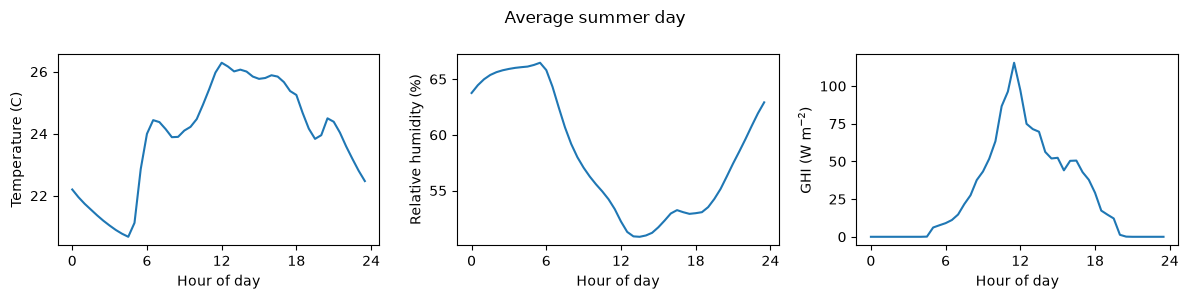

In [8]:
import matplotlib.pyplot as plt

hours = [t.hour + t.minute / 60 for t in average_day.index]
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharex=True)
for ax, (col, ylabel) in zip(axes, [
    ("Temperature", "Temperature (C)"),
    ("Relative Humidity", "Relative humidity (%)"),
    ("GHI", "GHI (W m$^{-2}$)"),
]):
    ax.plot(hours, average_day[col])
    ax.set_xlabel("Hour of day")
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(0, 25, 6))
fig.suptitle("Average summer day")
fig.tight_layout()
plt.show()

In [9]:
average_weather.to_excel(average_day_file, index=False)

print(f"Saved average-day input file: {average_day_file}")

Saved average-day input file: C:\Users\joshg\OneDrive\Documents\SourceCode\Photo3-Plant-Salinity-Traits\data\weather_data\lab_weather_data\Lab_Weather_Summer_Average_Day_30min.xlsx


## Notes

- To change the model timestep, edit `timestep_minutes` and rerun all cells.
- If datetime parsing fails, set `apogee_datetime_col` and `hobo_datetime_col` explicitly.
- If column names differ from defaults, update `apogee_ghi_col`, `hobo_rh_col`, and `hobo_temp_col`.
- If you need complete coverage instead of overlap only, set `join_how = "outer"` and optionally `interpolate_after_join = True`.
- The exported file includes `datetime` and is intended as the final model input file.
- The average-day file averages every time-of-day slot across all joined days (partial first/last days included) and starts at midnight of the first full day. Change its length with `average_day_replicate_days`.